In [17]:
import sys
import matplotlib as mpl
import seaborn as sns
import os
import torch
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import arviz as az
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

model_path = "/sternadi/home/volume3/yael/pycharm/MS2_PG/model"

if model_path in sys.path:
    sys.path.remove(model_path)
sys.path.insert(0, model_path)

from parameters_model_AB import modelA_priors, modelB_priors, pop_size_A, gene_probs, syn_probs_by_gene, passages
from simulator_model_AB import simulate as simulate_AB

In [44]:
model_A_collective_posterior_samples_path = '/sternadi/home/volume3/yael/model_AB/model_A/A1/results_weak_ada_def/new_collective_MOI01_samples.csv'
model_A_collective_posterior_stats_path='/sternadi/home/volume3/yael/model_AB/model_A/A1/results_weak_ada_def/collective_MOI01_stats.csv'
model_B_collective_EHG_samples_path = '/sternadi/home/volume3/yael/model_AB/model_B/B_weak_ada_def/results_weak_ada_def/new_collective_EGH_samples.csv'
model_B_collective_EHG_stats_path = '/sternadi/home/volume3/yael/model_AB/model_B/B_weak_ada_def/results_weak_ada_def/model_B_new_collective_EHG_stats.csv'


model_B_weakada_def_control_line1_samples_path = '/sternadi/home/volume3/yael/model_AB/model_B/B_weak_ada_def/B_control/results_line1/MOI0.1_line_1_20k_samples_80k_weakada_posterior_samples.csv'
model_B_weakada_def_control_line1_stats_path = '/sternadi/home/volume3/yael/model_AB/model_B/B_weak_ada_def/B_control/results_line1/MOI0.1_line_1_20k_samples_80k_weakada_stats.csv'
model_B_weakada_def_control_line2_samples_path = '/sternadi/home/volume3/yael/model_AB/model_B/B_weak_ada_def/B_control/results_line2/MOI0.1_line_2_20k_samples_80k_weakada_posterior_samples.csv'
model_B_weakada_def_control_line2_stats_path = '/sternadi/home/volume3/yael/model_AB/model_B/B_weak_ada_def/B_control/results_line2/MOI0.1_line_2_20k_samples_80k_weakada_stats.csv'
model_B_weakada_def_control_line3_samples_path = '/sternadi/home/volume3/yael/model_AB/model_B/B_weak_ada_def/B_control/results_line3/MOI0.1_line_3_20k_samples_80k_weakada_posterior_samples.csv'
model_B_weakada_def_control_line3_stats_path = '/sternadi/home/volume3/yael/model_AB/model_B/B_weak_ada_def/B_control/results_line3/MOI0.1_line_3_20k_samples_80k_weakada_stats.csv'

modelA_test_results_path = '/sternadi/home/volume3/yael/model_AB/model_A/A1/nn_performance_test_1/nn_test_2k_sims_2/nn_test_results_2k_sims.csv'
nn_test_modelB_weakada_output_path = '/sternadi/home/volume3/yael/model_AB/model_B/B_weak_ada_def/nn_performance/nn_test_results_2k_sims.csv'

moi10_sumstat_path = '/sternadi/home/volume3/yael/Data/MOI10/moi10_sumstats_by_line.pkl'
moi01_sumstat_path = '/sternadi/home/volume3/yael/Data/MOI01/moi01_sumstats_by_line.pkl'

In [45]:
def get_emp_sumstats_dict(emp_smst_path):
    with open(emp_smst_path, 'rb') as f:
        emp_sumstat_by_line_dict = pickle.load(f)
    return {key: val for key,val in emp_sumstat_by_line_dict.items() if key!='A'}

In [46]:
emp_dict_01 = get_emp_sumstats_dict(moi01_sumstat_path)
emp_dict_10 = get_emp_sumstats_dict(moi10_sumstat_path)

In [19]:
def plot_posteriors_overlay(
    post_dfs,
    stats_list,
    save_plot,
    plot_output_dir,
    plot_name,
    param_2_name,
    priors_dict=None,
    params_to_use=None, # lst of parameters to use
    bins=50,
    labels=None,
    colors=None,
    alpha=0.35,
    ncols=3,
    figsize_per_row=4.0,
):
    """
    Overlay up to 3 posterior histograms per parameter (same axes), add 95% HDI per posterior,
    and optionally overlay a Uniform prior. Uses a single shared legend for the whole figure.

    Parameters
    ----------
    post_dfs : list[pd.DataFrame]
        List of posterior samples dataframes. Length must be 1..3. Each df columns are parameters.
    stats_list : list[pd.DataFrame]
        List of stats tables corresponding to post_dfs. Length must match post_dfs.
        Each stats df must contain columns: ['param', HDI_low', 'HDI_high'].
    param_2_name : dict
        Mapping from parameter column name -> display name.
    priors_dict : dict, optional
        { 'param_name': (low, high) } for uniform priors.

    """

    if not isinstance(post_dfs, (list, tuple)) or len(post_dfs) == 0:
        raise ValueError("post_dfs must be a non-empty list/tuple of DataFrames (length 1..3).")
    if len(post_dfs) > 4:
        raise ValueError(f"Supports up to 3 posteriors, got {len(post_dfs)}.")
    if not isinstance(stats_list, (list, tuple)) or len(stats_list) != len(post_dfs):
        raise ValueError("stats_list must be a list/tuple with the same length as post_dfs.")

    k = len(post_dfs)
    # Defaults
    if labels is None:
        labels = [f"Posterior {i+1}" for i in range(k)]
    if len(labels) != k:
        raise ValueError("labels length must match number of posteriors.")

    if colors is None:
        colors = ["tab:blue", "tab:green", "tab:purple", "tab:orange"][:k]
    if len(colors) != k:
        raise ValueError("colors length must match number of posteriors.")

    # Ensure same parameter set across dfs
    cols0 = list(post_dfs[0].columns)
    set0 = set(cols0)
    for idx, df in enumerate(post_dfs[1:], start=2):
        if set(df.columns) != set0:
            missing = set0 - set(df.columns)
            extra = set(df.columns) - set0
            raise ValueError(
                f"All post_dfs must have the same columns.\n"
                f"Mismatch at post_dfs[{idx-1}]. Missing: {sorted(missing)}; Extra: {sorted(extra)}"
            )

    cols = cols0
    if params_to_use==None:
        params_to_plot = list(priors_dict.keys())
    else:
        params_to_plot = params_to_use
        
    n_params = len(params_to_plot)

    nrows = int(np.ceil(n_params / ncols))
    figsize = (18, figsize_per_row * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    fig.set_dpi(300)
    axes_flat = np.array(axes).flatten()

    legend_handles = {}
    prior_present = False

    for i, col in enumerate(params_to_plot):
        ax = axes_flat[i]

        all_vals = []
        for df in post_dfs:
            v = df[col].values
            v = v[np.isfinite(v)]
            if v.size:
                all_vals.append(v)

        if not all_vals:
            # No finite values in any posterior for this param
            ax.set_title(f"{param_2_name.get(col, col)}", fontweight="medium", fontsize=20, pad=15)
            ax.text(0.5, 0.5, "No finite samples", ha="center", va="center", transform=ax.transAxes)
            ax.axis("off")
            continue

        x_min = min(np.min(v) for v in all_vals)
        x_max = max(np.max(v) for v in all_vals)

        if priors_dict and col in priors_dict:
            prior_low, prior_high = priors_dict[col]
            x_min = min(x_min, prior_low)
            x_max = max(x_max, prior_high)  # min instead of max if we dont want the full prior limits

        pad = 0.05 * (x_max - x_min) if x_max > x_min else 1.0
        ax.set_xlim(x_min - pad, x_max + pad)

        # Plot each posterior + HDI
        for j in range(k):
            vals = post_dfs[j][col].values
            vals = vals[np.isfinite(vals)]
            post_label = f'Posterior ({labels[j]})'
            h = ax.hist(
                vals,
                bins=bins,
                density=True,
                alpha=alpha,
                color=colors[j],
                label=post_label,  # for legend collection
            )
            # hist returns (n, bins, patches)
            if post_label not in legend_handles: # labels[j]
                legend_handles[post_label] = h[2][0]  # labels[j]

            # HDI
            st = stats_list[j]
            row = st.loc[st["param"] == col]
            if not row.empty:
                map_val = row["MAP"].values[0]
                hdi_low = row["HDI_low"].values[0]
                hdi_high = row["HDI_high"].values[0]

                # HDI span
                hdi_label = f"95% HDI ({labels[j]})"
                span = ax.axvspan(hdi_low, hdi_high, color=colors[j], alpha=0.12, label=hdi_label)
                if hdi_label not in legend_handles:
                    legend_handles[hdi_label] = span

        # Prior overlay
        if priors_dict and col in priors_dict:
            prior_low, prior_high = priors_dict[col]
            if prior_high <= prior_low:
                raise ValueError(f"Invalid prior range for {col}: ({prior_low}, {prior_high})")
            prior_height = 1.0 / (prior_high - prior_low)
            prior_line = ax.hlines(
                y=prior_height,
                xmin=prior_low,
                xmax=prior_high,
                color="goldenrod",  # darkorange
                linewidth=2,
                label="Prior",
            )
            prior_present = True
            if "Prior" not in legend_handles:
                legend_handles["Prior"] = prior_line

        ax.set_title(f"{param_2_name.get(col, col)}", fontweight="medium", fontsize=20, pad=15)
        if i % ncols == 0:
            ax.set_ylabel("Density", fontsize=18, labelpad=15)

    for j in range(n_params, len(axes_flat)):
        axes_flat[j].axis("off")

    # Shared legend for the whole figure
    ordered_keys = []
    ordered_keys += labels
    for lab in labels:
        ordered_keys.append(f"Posterior ({lab})")
        ordered_keys.append(f"MAP ({lab})")
        ordered_keys.append(f"95% HDI ({lab})")
    if prior_present:
        ordered_keys.append("Prior")

    handles = [legend_handles[k] for k in ordered_keys if k in legend_handles]
    leg_labels = [k for k in ordered_keys if k in legend_handles]

    fig.legend(
        handles,
        leg_labels,
        loc="upper center",
        ncol=min(len(leg_labels), 4),
        frameon=True,
        fontsize=16,
        bbox_to_anchor=(0.5, -0.02),
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])  

    if save_plot:
        os.makedirs(plot_output_dir, exist_ok=True)
        save_path = os.path.join(plot_output_dir, f"{plot_name}.png")
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Saved posterior plot to {save_path}")
        plt.close(fig)
    else:
        plt.show()

In [20]:
def plot_posteriors_overlay_wraper(posterior_samples_path_lst, stats_path_lst,model,param_2_name,labels,params_to_use=None, plot_output_dir=None,ncols=3,colors=None):
    stats_df_lst = []
    posterior_samples_df_lst = []
    for i in range(len(posterior_samples_path_lst)):
        posterior_samples_df_lst.append(pd.read_csv(posterior_samples_path_lst[i]))
        stats_df_lst.append(pd.read_csv(stats_path_lst[i]))
    priors_dict = modelA_priors if model == 'A' else modelB_priors
    save_fig = False if plot_output_dir is None else True
    plot_posteriors_overlay(posterior_samples_df_lst,stats_df_lst,save_fig,plot_output_dir,'',param_2_name,priors_dict,labels=labels,params_to_use=params_to_use,ncols=ncols,colors=colors)

In [21]:
param_2_name= {
    'mu': r'Mutation Rate',
    'w_syn': r'Synonymous effect',
    'w_nonsyn_mat': r'Maturation non-syn effect',
    'w_nonsyn_cp': r'Coat portein non-syn effect',
    'w_nonsyn_lys': r'Lysis non-syn effect',
    'w_nonsyn_rep': r'Replicase non-syn effect',
    'w_ada': r'Adaptive effect',
    'p_ada_syn': r'Adaptive syn probability',
    "p_ada_ns_mat": r'Maturation adaptive' + '\n' + r'non-syn probabililty',
    "p_ada_ns_cp": r'Coat protein adaptive'+ '\n' + r'non-syn probabililty',
    "p_ada_ns_lys": r'Lysis adaptive'+ '\n' + r'non-syn probabililty',
    "p_ada_ns_rep": r'Replicase adaptive'+ '\n' + r'non-syn probabililty',
    "p_mat_nonsyn_rec": r'Maturation'+ '\n' + r'recessive probabililty',
    "p_cp_nonsyn_rec": r'Coat portein'+ '\n' + r'recessive probabililty',
    "p_lys_nonsyn_rec": r'Lysis'+ '\n' + r'recessive probabililty',
    "p_rep_nonsyn_rec": r'Replicase'+ '\n' + r'recessive probabililty',
}

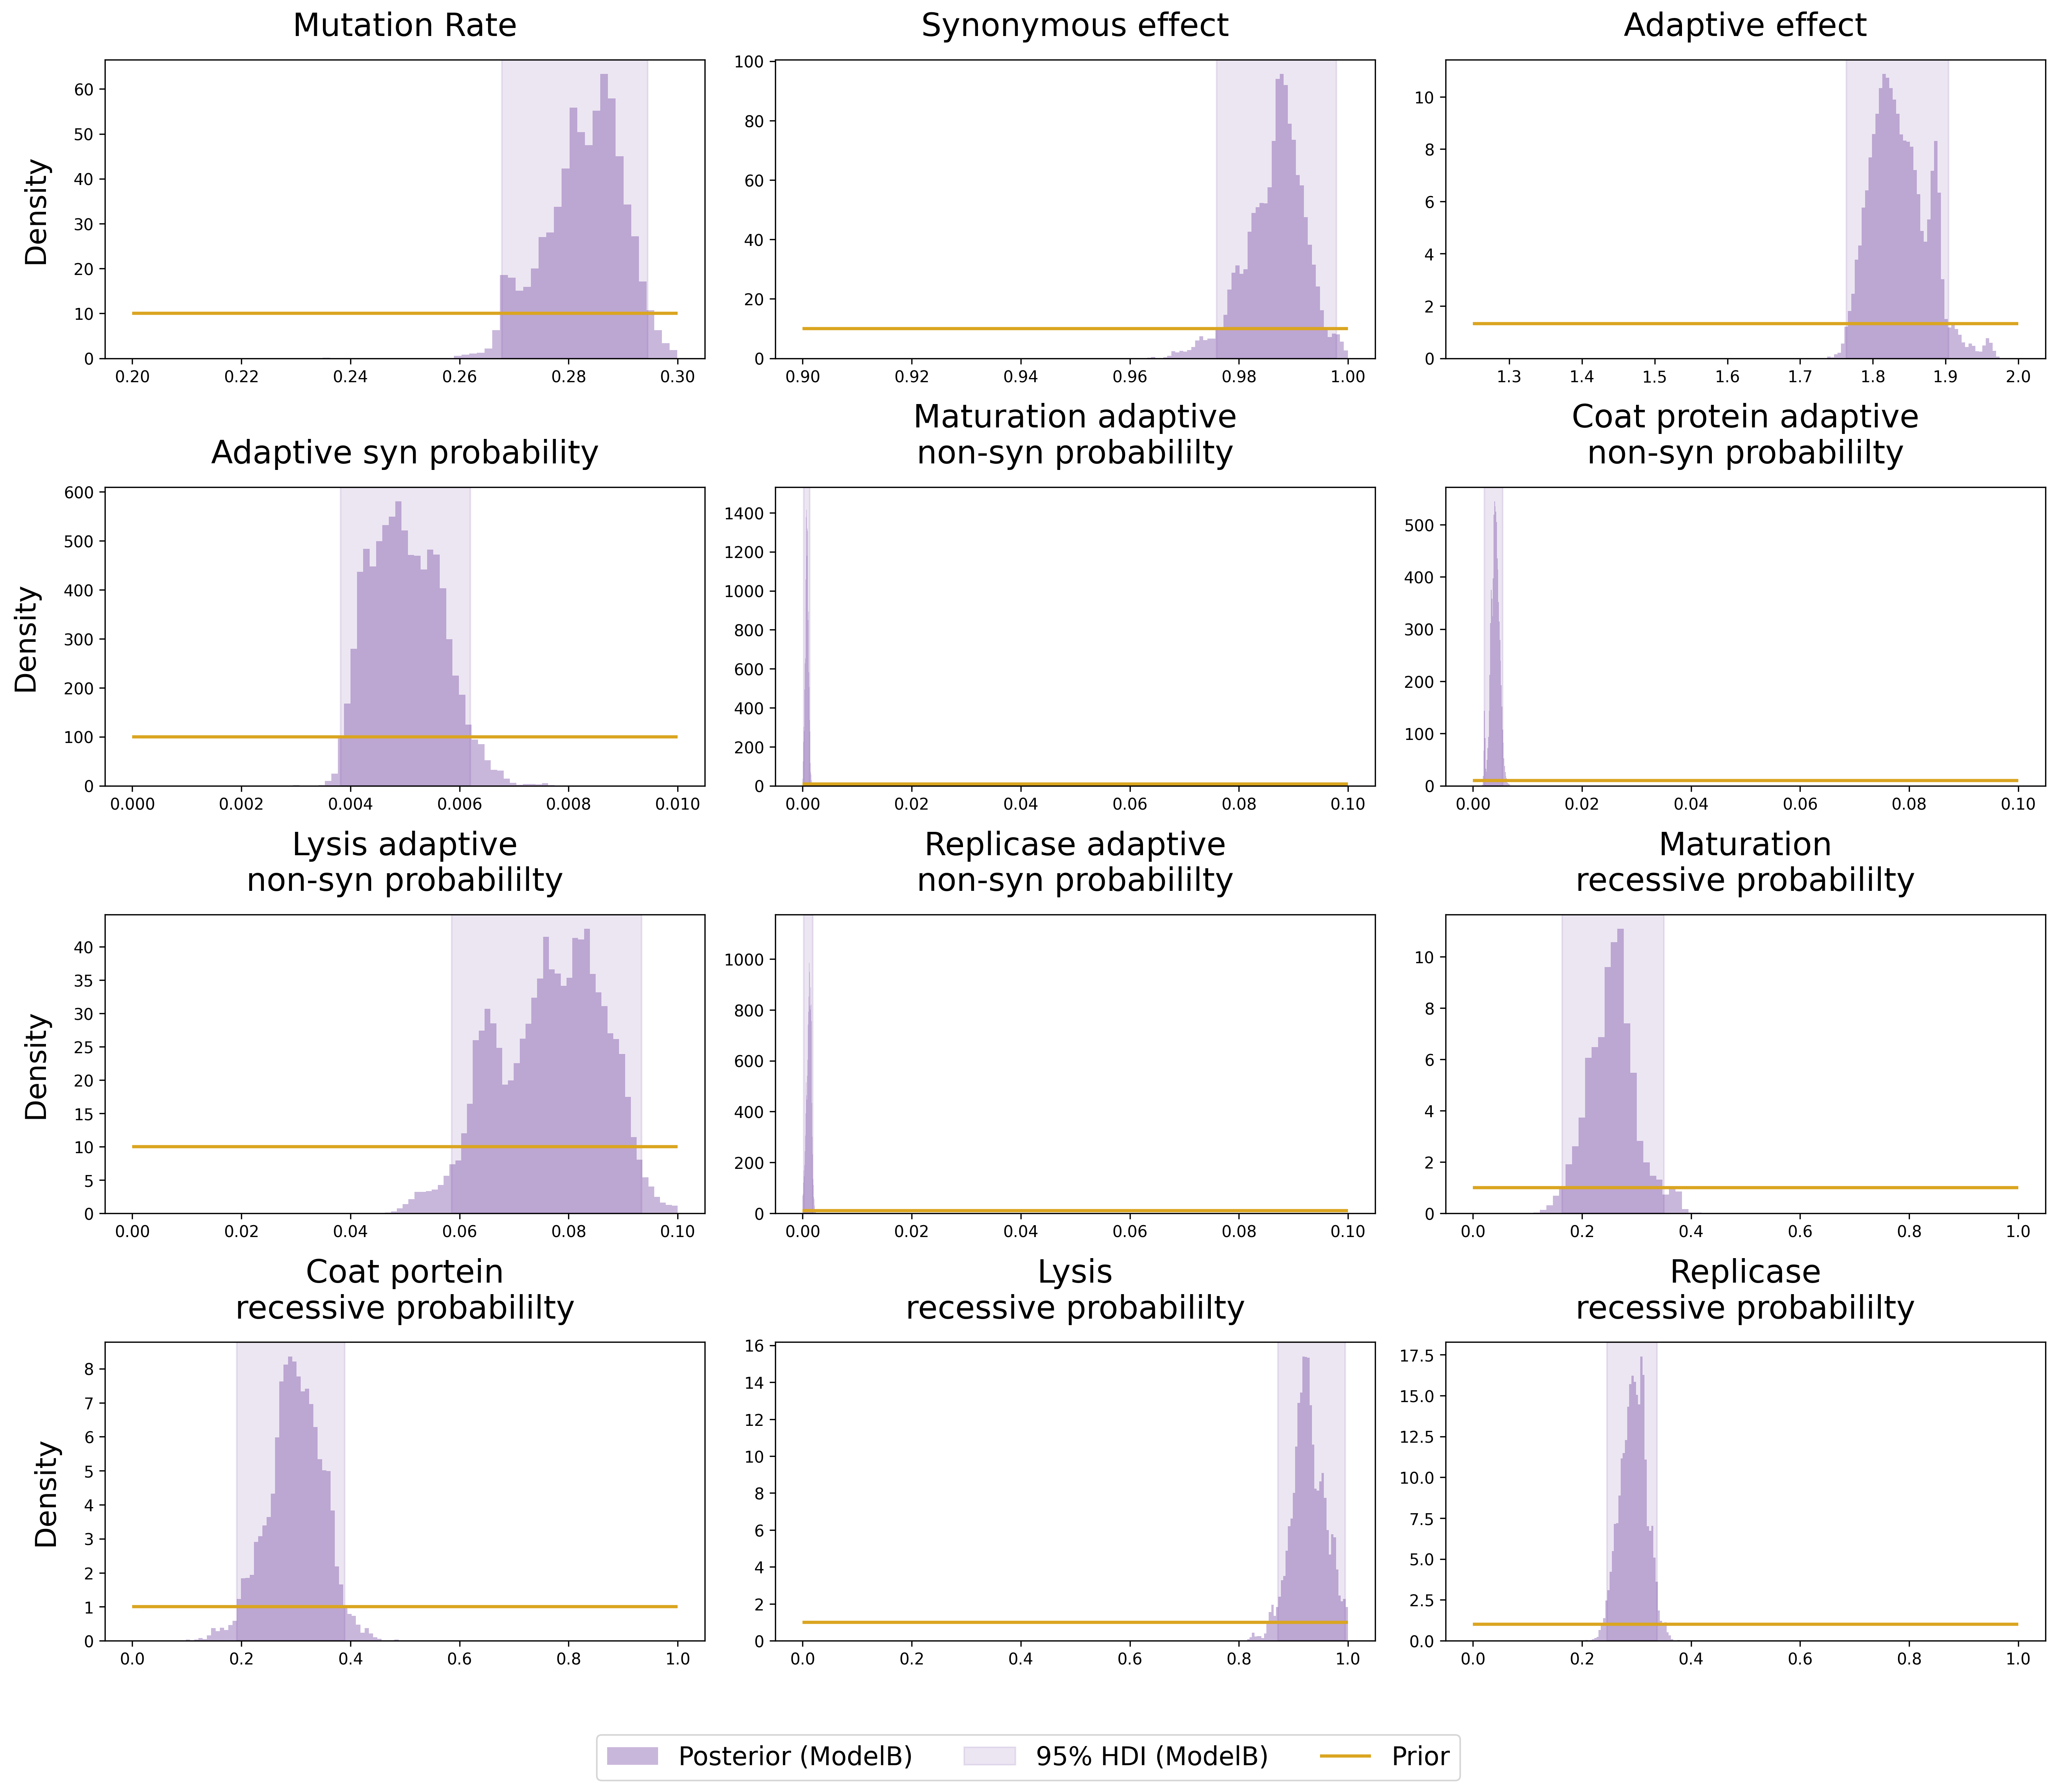

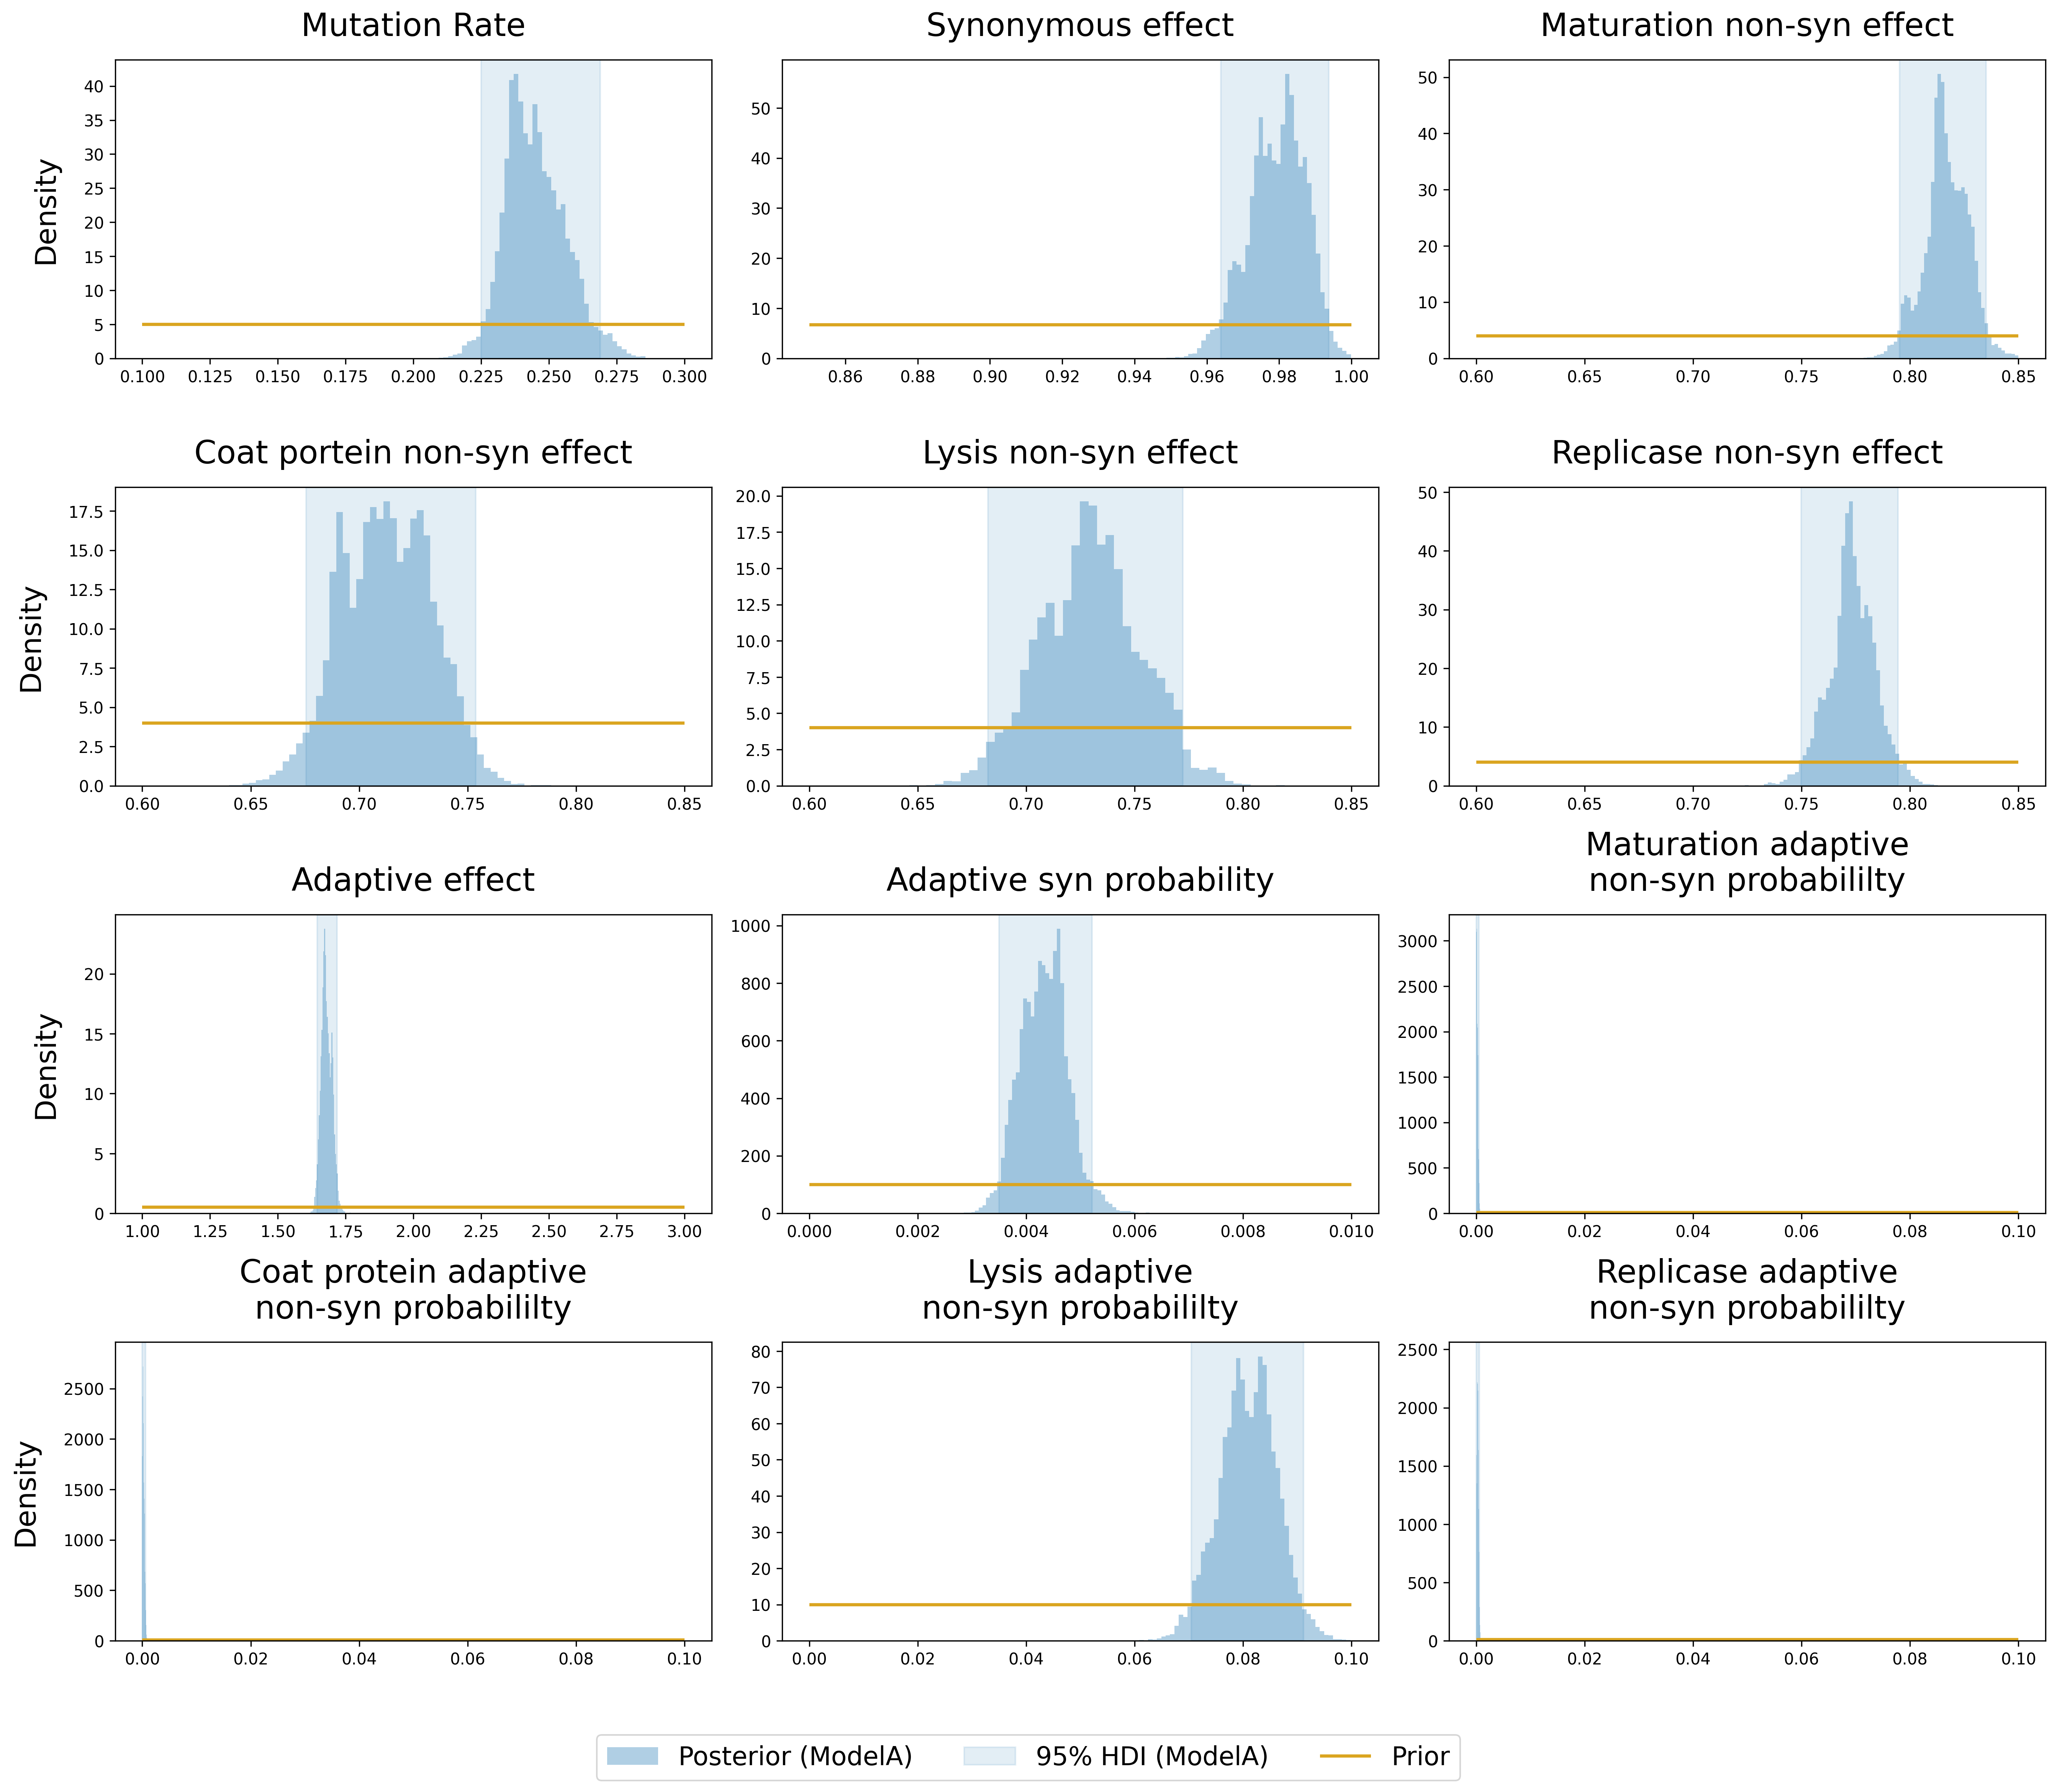

In [22]:
plot_posteriors_overlay_wraper(
    [model_B_new_collective_EHG_samples_path],
    [model_B_new_collective_EHG_stats_path],
    'B',
    param_2_name,
    labels=['ModelB'],
    colors=['rebeccapurple']
) 

plot_posteriors_overlay_wraper(
    [model_A_collective_posterior_samples_path],
    [model_A_collective_posterior_stats_path],
    'A',
    param_2_name,
    labels=['ModelA']
) 

In [6]:
def plot_empirical_vs_control_recessive_posteriors(
    empirical_posterior_samples_path_lst,
    empirical_stats_path_lst,
    control_posterior_samples_path_lst,
    control_stats_path_lst,
    param_2_name,
    priors_dict,
    empirical_labels=("lineE", "lineG", "lineH"),
    control_labels=("line1", "line2", "line3"),
    params_to_use=None,
    empirical_colors=None,
    control_colors=None,
    bins=50,
    alpha=0.5, # 0.35,
    hdi_alpha=0.12,
    save_fig=False,
    plot_output_dir=None,
    plot_name="empirical_vs_control_recessive_posteriors",
    figsize=(18, 8),
    dpi=300,
    sharex=True,
    sharey_by_column=False,
):
    """
    Make a 2 x 4 figure comparing empirical high-MOI inferred recessive-probability
    posteriors to low-MOI control posteriors.

    Rows:
        0 = empirical high-MOI posteriors
        1 = low-MOI control posteriors

    Columns:
        four recessive-probability parameters:
        p_mat_nonsyn_rec, p_cp_nonsyn_rec, p_lys_nonsyn_rec, p_rep_nonsyn_rec

    Required stats columns:
        ['param', 'MAP', 'HDI_low', 'HDI_high']

    Notes:
        - MAP is not plotted by default, to avoid clutter.
        - HDIs are shown as translucent spans.
        - Prior is shown as the horizontal orange line.
    """

    if params_to_use is None:
        params_to_use = [
            "p_mat_nonsyn_rec",
            "p_cp_nonsyn_rec",
            "p_lys_nonsyn_rec",
            "p_rep_nonsyn_rec",
        ]

    if empirical_colors is None:
        empirical_colors = ["tab:blue", "tab:orange", "tab:green"]

    if control_colors is None:
        control_colors = ["black", "gray", "slategray"]

    # -----------------------------
    # Load data
    # -----------------------------
    emp_post_dfs = [pd.read_csv(p) for p in empirical_posterior_samples_path_lst]
    emp_stats = [pd.read_csv(p) for p in empirical_stats_path_lst]

    ctrl_post_dfs = [pd.read_csv(p) for p in control_posterior_samples_path_lst]
    ctrl_stats = [pd.read_csv(p) for p in control_stats_path_lst]

    if len(emp_post_dfs) != len(emp_stats):
        raise ValueError("Empirical posterior and stats lists must have the same length.")

    if len(ctrl_post_dfs) != len(ctrl_stats):
        raise ValueError("Control posterior and stats lists must have the same length.")

    if len(emp_post_dfs) != len(empirical_labels):
        raise ValueError("empirical_labels length must match empirical posterior list length.")

    if len(ctrl_post_dfs) != len(control_labels):
        raise ValueError("control_labels length must match control posterior list length.")

    if len(empirical_colors) < len(emp_post_dfs):
        raise ValueError("Not enough empirical_colors for empirical posterior list.")

    if len(control_colors) < len(ctrl_post_dfs):
        raise ValueError("Not enough control_colors for control posterior list.")

    # -----------------------------
    # Create figure
    # -----------------------------
    fig, axes = plt.subplots(
        2,
        len(params_to_use),
        figsize=figsize,
        dpi=dpi,
        sharex=sharex,
        sharey=False,
    )

    if len(params_to_use) == 1:
        axes = np.array(axes).reshape(2, 1)

    row_info = [
        {
            "row": 0,
            "title": "Empirical high MOI",
            "post_dfs": emp_post_dfs,
            "stats": emp_stats,
            "labels": empirical_labels,
            "colors": empirical_colors,
        },
        {
            "row": 1,
            "title": "Low-MOI control",
            "post_dfs": ctrl_post_dfs,
            "stats": ctrl_stats,
            "labels": control_labels,
            "colors": control_colors,
        },
    ]

    # -----------------------------
    # Plot
    # -----------------------------
    for c, param in enumerate(params_to_use):
        for info in row_info:
            r = info["row"]
            ax = axes[r, c]

            # Determine x range from prior, so empirical/control are visually comparable
            if priors_dict is not None and param in priors_dict:
                prior_low, prior_high = priors_dict[param]
                x_min, x_max = prior_low, prior_high
            else:
                all_vals = []
                for df in info["post_dfs"]:
                    vals = df[param].values
                    vals = vals[np.isfinite(vals)]
                    all_vals.append(vals)
                x_min = min(np.min(v) for v in all_vals)
                x_max = max(np.max(v) for v in all_vals)

            pad = 0.03 * (x_max - x_min)
            ax.set_xlim(x_min - pad, x_max + pad)

            # Posterior histograms and HDIs
            for j, df in enumerate(info["post_dfs"]):
                vals = df[param].values
                vals = vals[np.isfinite(vals)]

                ax.hist(
                    vals,
                    bins=bins,
                    density=True,
                    alpha=alpha,
                    color=info["colors"][j],
                )

                st = info["stats"][j]
                row = st.loc[st["param"] == param]

                if not row.empty:
                    hdi_low = row["HDI_low"].values[0]
                    hdi_high = row["HDI_high"].values[0]

                    ax.axvspan(
                        hdi_low,
                        hdi_high,
                        color=info["colors"][j],
                        alpha=hdi_alpha,
                    )

            if r == 0:
                ax.set_title(
                    param_2_name.get(param, param),
                    fontsize=20,
                    fontweight="medium",
                    pad=12,
                )

            if c == 0:
                ax.set_ylabel(f"{info['title']}\nDensity", fontsize=18,labelpad=15) 

            if r == 1:
                ax.set_xlabel("Recessive probability", fontsize=18,labelpad=15)

            ax.tick_params(axis="both", labelsize=16)

    # make y limits comparable within each protein column
    if sharey_by_column:
        for c in range(len(params_to_use)):
            ymax = max(axes[0, c].get_ylim()[1], axes[1, c].get_ylim()[1])
            axes[0, c].set_ylim(0, ymax)
            axes[1, c].set_ylim(0, ymax)

    # -----------------------------
    # Shared legend
    # -----------------------------
    legend_handles = []

    for lab, col in zip(empirical_labels, empirical_colors):
        legend_handles.append(
            Patch(facecolor=col, alpha=alpha, label=f"Empirical posterior ({lab})")
        )

    for lab, col in zip(control_labels, control_colors):
        legend_handles.append(
            Patch(facecolor=col, alpha=alpha, label=f"Control posterior ({lab})")
        )

    legend_handles.append(
        Patch(facecolor="gray", alpha=hdi_alpha, label="95% HDI")
    )


    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=4,
        frameon=True,
        fontsize=18,
        bbox_to_anchor=(0.5, -0.05),
    )


    plt.tight_layout(rect=[0, 0.06, 1, 0.98])

    if save_fig:
        if plot_output_dir is None:
            raise ValueError("plot_output_dir must be provided when save_fig=True.")

        os.makedirs(plot_output_dir, exist_ok=True)
        save_path = os.path.join(plot_output_dir, f"{plot_name}.png")
        plt.savefig(save_path, bbox_inches="tight", dpi=dpi)
        print(f"Saved plot to {save_path}")
        plt.close(fig)
    else:
        plt.show()

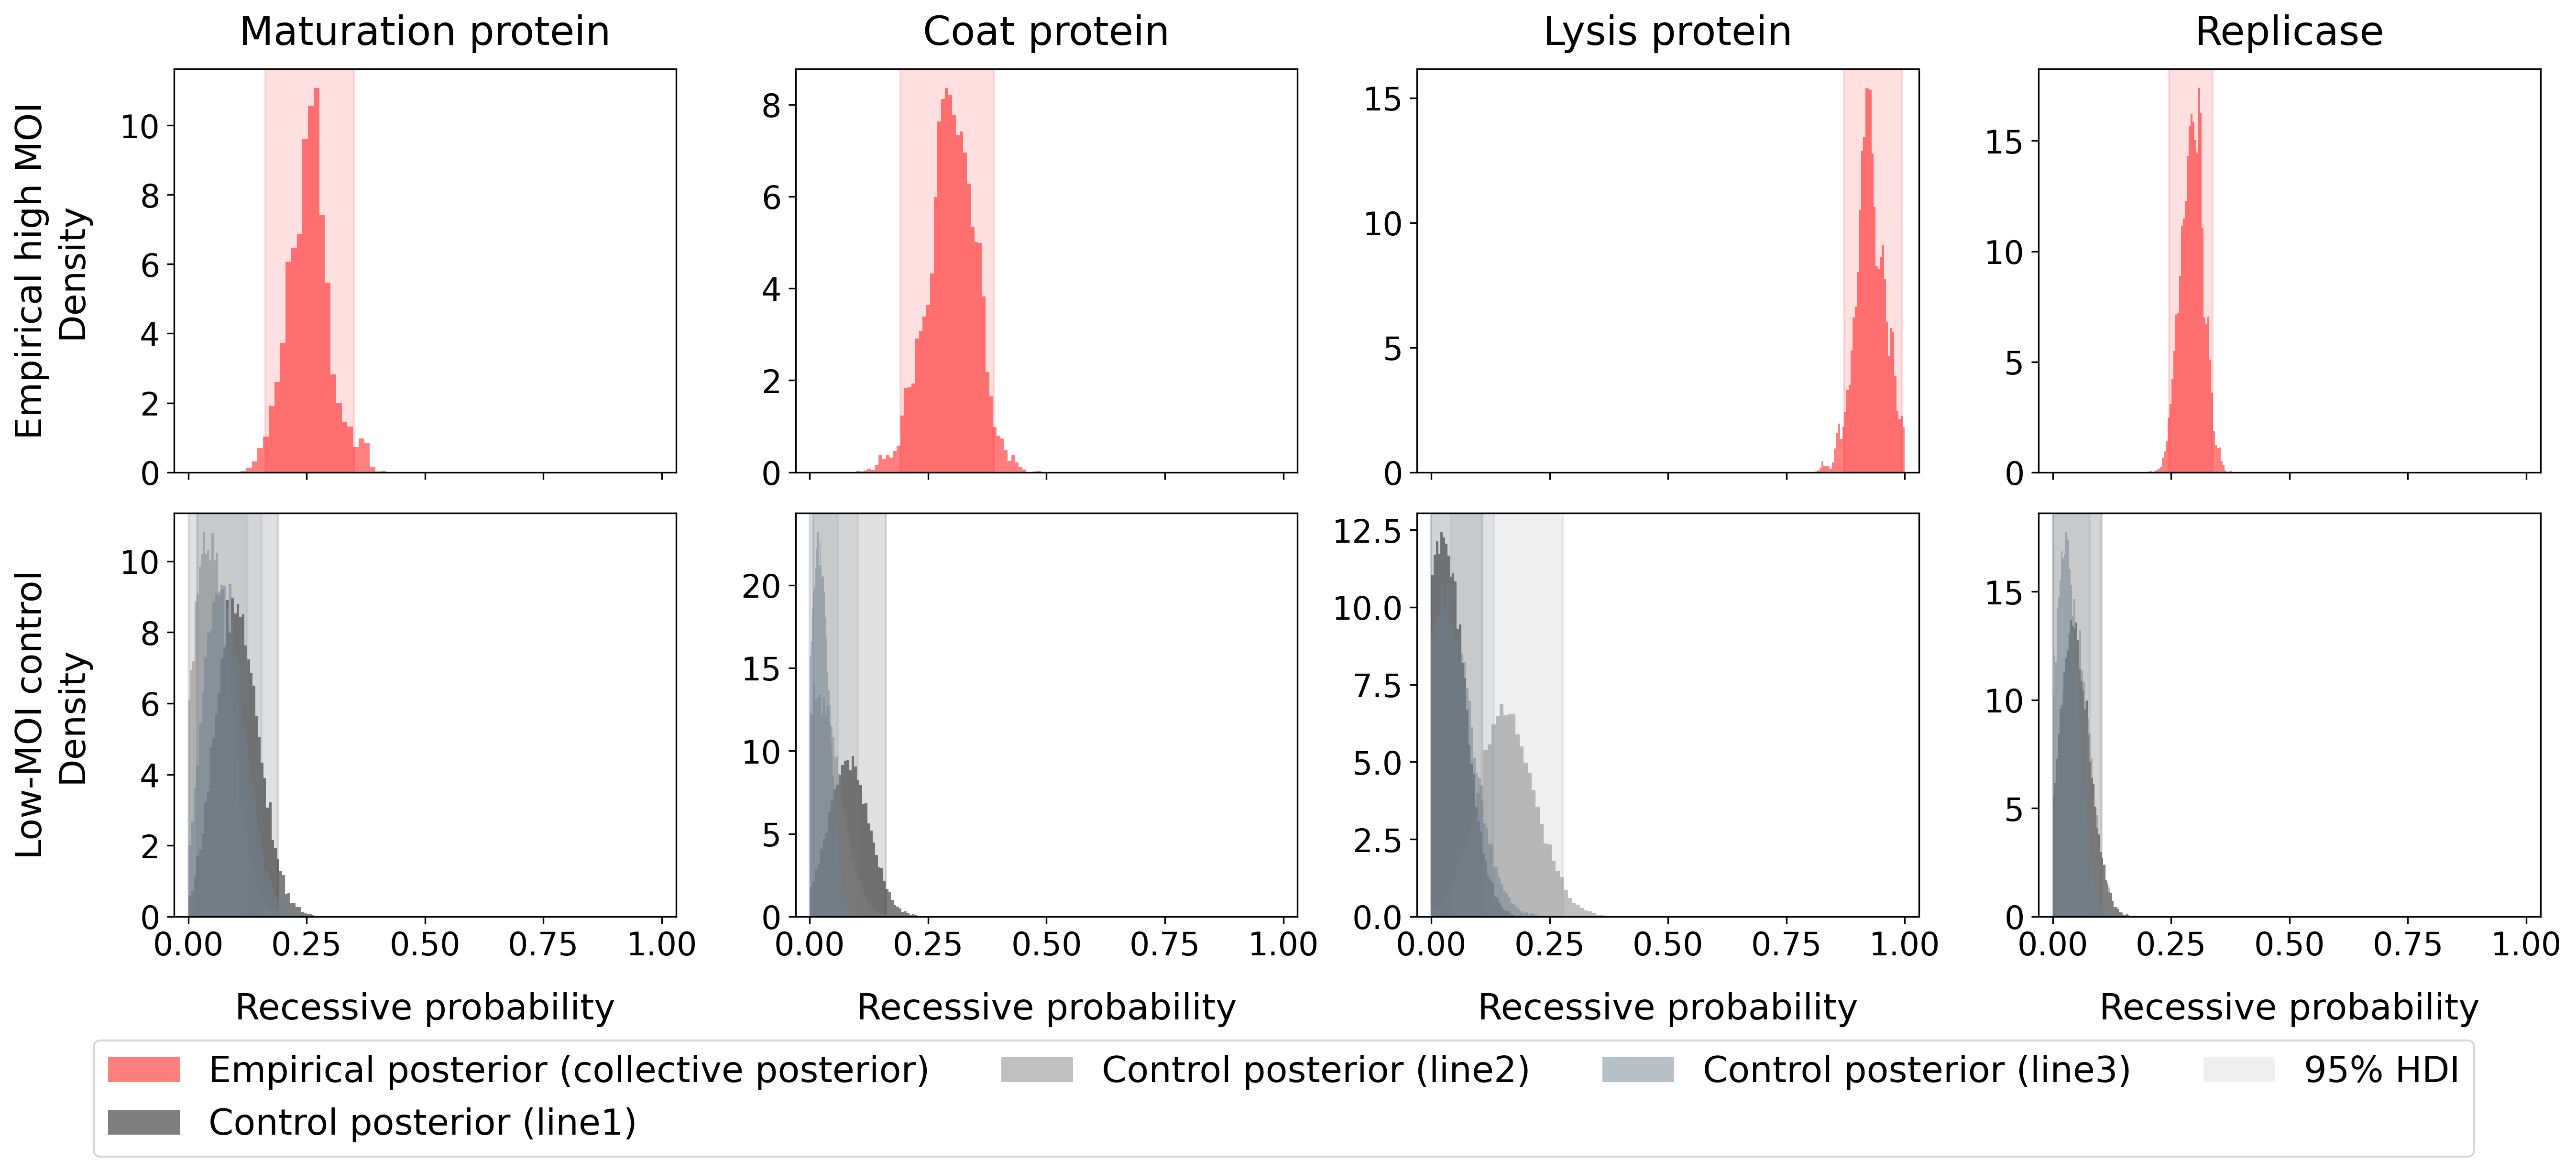

In [10]:
posterior_samples_B_weakada_def_control_path_lst = [model_B_weakada_def_control_line1_samples_path,model_B_weakada_def_control_line2_samples_path,model_B_weakada_def_control_line3_samples_path]
stats_B_weakada_def_control_path_lst = [model_B_weakada_def_control_line1_stats_path,model_B_weakada_def_control_line2_stats_path,model_B_weakada_def_control_line3_stats_path]
rec_params = [
    "p_mat_nonsyn_rec",
    "p_cp_nonsyn_rec",
    "p_lys_nonsyn_rec",
    "p_rep_nonsyn_rec",
]
recessive_param_2_name = {
    "p_mat_nonsyn_rec": r"Maturation protein",
    "p_cp_nonsyn_rec": r"Coat protein",
    "p_lys_nonsyn_rec": r"Lysis protein",
    "p_rep_nonsyn_rec": r"Replicase",
}

plot_empirical_vs_control_recessive_posteriors(
    empirical_posterior_samples_path_lst=[model_B_new_collective_EHG_samples_path],
    empirical_stats_path_lst=[model_B_new_collective_EHG_stats_path],
    control_posterior_samples_path_lst=posterior_samples_B_weakada_def_control_path_lst,
    control_stats_path_lst=stats_B_weakada_def_control_path_lst,
    param_2_name=recessive_param_2_name,
    priors_dict=modelB_priors,
    empirical_colors="red",
    empirical_labels=["collective posterior"],
    control_labels=["line1", "line2", "line3"],
    params_to_use=rec_params,
    save_fig=False,
    plot_name="empirical_collective_vs_control_recessive_probabilities",
)

## Hierarchical beta binomial model

In [25]:
ns_05percent_path = '/sternadi/home/volume3/yael/Data/Hierarchical_betabin_results/ns_05percent.pkl'
ns_1percent_path = '/sternadi/home/volume3/yael/Data/Hierarchical_betabin_results/ns_1percent.pkl'
ns_2percent_path = '/sternadi/home/volume3/yael/Data/Hierarchical_betabin_results/ns_2percent.pkl'

syn_05percent_path = '/sternadi/home/volume3/yael/Data/Hierarchical_betabin_results/syn_05percent.pkl'
syn_1percent_path = '/sternadi/home/volume3/yael/Data/Hierarchical_betabin_results/syn_1percent.pkl'
syn_2percent_path = '/sternadi/home/volume3/yael/Data/Hierarchical_betabin_results/syn_2percent.pkl'

In [26]:
ns_05percent = pd.read_pickle(ns_05percent_path)
ns_1percent = pd.read_pickle(ns_1percent_path)
ns_2percent = pd.read_pickle(ns_2percent_path)

syn_05percent = pd.read_pickle(syn_05percent_path)
syn_1percent = pd.read_pickle(syn_1percent_path)
syn_2percent = pd.read_pickle(syn_2percent_path)


In [27]:
def plot_moi_forest(
    summary_df,
    prob_positive=None,
    protein_labels=None,
    protein_order=("mat", "cp", "lys", "rep"),
    mean_col="mean",
    lo_col="hdi_2.5%",
    hi_col="hdi_97.5%",
    xlabel="High-MOI effect on expected mutation frequency (logit scale)",
    color="#d6532b",
    row_spacing=0.55,
    figsize=None,
    out_path=None,
):
    """
    Build a forest plot of MOI10 effects per protein.
 
    Parameters
    ----------
    summary_df : pd.DataFrame
        Output of az.summary(trace, var_names=["moi10_effect"], ...),
        or any df with a row per protein and mean/hdi_2.5%/hdi_97.5% columns.
        Index entries are expected to look like "moi10_effect[mat]" (arviz
        default) OR just "mat" (already cleaned) OR have a "protein" column.
    prob_positive : pd.DataFrame or pd.Series or None
        P(effect > 0) per protein. If a DataFrame (as returned by
        summarize_moi_model), expects a "protein" column/index and a column
        containing "P(MOI10 effect > 0)" (or similar). If None, looks for a
        "P(>0)" column in summary_df instead.
    protein_labels : dict or None
        Mapping from internal protein code to display label,
        e.g. {"mat": "Maturation", "cp": "Coat", "lys": "Lysis", "rep": "Replicase"}.
        Defaults to title-casing the protein name if not provided.
    protein_order : tuple
        Order (bottom-to-top will be reversed automatically so the first
        listed protein appears at the top, matching typical forest plots).
    mean_col, lo_col, hi_col : str
        Column names for point estimate and HDI bounds.
    xlabel : str
        X-axis label.
    color : str
        Marker/line color.
    row_spacing : float
        Vertical distance between adjacent protein rows. 1.0 is
        matplotlib's natural spacing; values below 1.0 (default 0.55)
        pack the proteins closer together. Lower this further for even
        tighter padding.
    figsize : tuple or None
        Figure size. If None, height auto-scales with row_spacing and the
        number of proteins, so tighter spacing also yields a shorter
        figure instead of leaving empty space top/bottom.
    out_path : str or None
        If given, saves the figure to this path (png/pdf inferred from extension).
 
    Returns
    -------
    fig, ax
    """
 
    df = summary_df.copy()
 
    # --- Normalize index/protein column ---
    if "protein" not in df.columns:
        # try to extract protein name from index like "moi10_effect[mat]"
        idx = pd.Series(df.index.astype(str), index=df.index)
        extracted = idx.str.extract(r"\[(.*)\]")[0]
        df["protein"] = extracted.fillna(idx)
    df = df.set_index("protein")
 
    # --- Reindex to desired protein order ---
    df = df.loc[[p for p in protein_order if p in df.index]]
 
    # --- Default labels ---
    if protein_labels is None:
        protein_labels = {
            "mat": "Maturation",
            "cp": "Coat",
            "lys": "Lysis",
            "rep": "Replicase",
        }
    labels = [protein_labels.get(p, p.title()) for p in df.index]
 
    # --- Resolve P(>0) values ---
    if prob_positive is not None:
        pp = prob_positive.copy()
        if isinstance(pp, pd.Series):
            pp_vals = pp.reindex(df.index)
        else:
            if "protein" in pp.columns:
                pp = pp.set_index("protein")
            elif pp.index.name != "protein":
                idx = pd.Series(pp.index.astype(str), index=pp.index)
                extracted = idx.str.extract(r"\[(.*)\]")[0]
                pp.index = extracted.fillna(idx).values
            prob_col = [c for c in pp.columns if "P(" in str(c)]
            pp_vals = pp[prob_col[0]].reindex(df.index) if prob_col else pp.iloc[:, 0].reindex(df.index)
    elif "P(>0)" in df.columns:
        pp_vals = df["P(>0)"]
    else:
        pp_vals = pd.Series([np.nan] * len(df), index=df.index)
 
    means = df[mean_col].values
    los = df[lo_col].values
    his = df[hi_col].values
    n_prot = len(df)
    y_pos = np.arange(n_prot)[::-1] * row_spacing  # first protein on top
 
    if figsize is None:
        height = max(2.0, 0.9 + n_prot * row_spacing * 1.0)
        figsize = (9, height)
 
    fig, ax = plt.subplots(figsize=figsize)
 
    ax.errorbar(
        means, y_pos,
        xerr=[means - los, his - means],
        fmt="o",
        color=color,
        ecolor=color,
        elinewidth=1.5,
        capsize=0,
        markersize=8,
        markeredgecolor=color,
    )
 
    ax.axvline(0, color="grey", linestyle="--", linewidth=1, zorder=0)
 
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=16)
    ax.set_xlabel(xlabel, fontsize=14)
 
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis="y", length=0)
 
    ax.set_ylim(y_pos.min() - 0.5 * row_spacing, y_pos.max() + 0.5 * row_spacing)
 
    # P(>0) annotations on the right, aligned to each protein's row
    trans = ax.get_yaxis_transform()  # x in axes coords, y in data coords
    for y, p in zip(y_pos, pp_vals.values):
        if pd.notna(p):
            ax.text(
                1.02, y,
                f"P(>0)={p:.2f}",
                transform=trans,
                ha="left", va="center", fontsize=14,
                clip_on=False,
            )
 
    fig.subplots_adjust(right=0.78)
 
    if out_path:
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
 
    return fig, ax

(<Figure size 900x310 with 1 Axes>,
 <Axes: xlabel='High-MOI effect on expected mutation frequency (logit scale)'>)

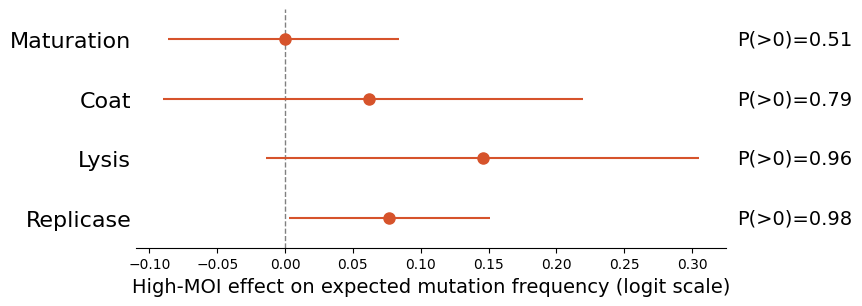

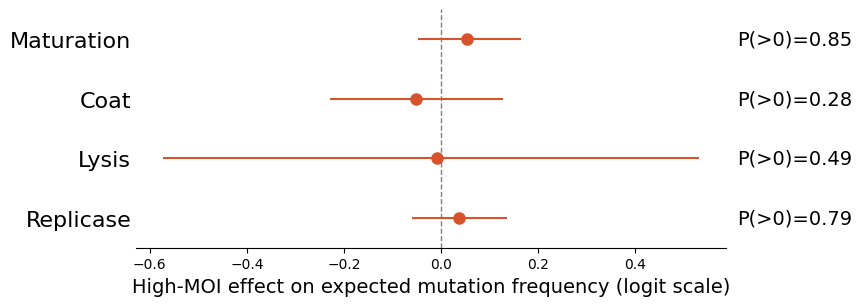

In [28]:
plot_moi_forest(ns_1percent['summary'], ns_1percent['prob_positive'])
plot_moi_forest(syn_1percent['summary'], syn_1percent['prob_positive'])

In [31]:
def _resolve_protein_df(summary_df, protein_order):
    """Shared helper: normalize a summary df to be indexed by protein,
    reordered to protein_order."""
    df = summary_df.copy()
    if "protein" not in df.columns:
        idx = pd.Series(df.index.astype(str), index=df.index)
        extracted = idx.str.extract(r"\[(.*)\]")[0]
        df["protein"] = extracted.fillna(idx)
    df = df.set_index("protein")
    return df.loc[[p for p in protein_order if p in df.index]]
 
 
def _resolve_prob_positive(prob_positive, protein_order):
    """Shared helper: normalize a prob_positive df/series to a Series
    indexed by protein, reordered to protein_order."""
    pp = prob_positive.copy()
    if isinstance(pp, pd.Series):
        pp_vals = pp.reindex(protein_order)
    else:
        if "protein" in pp.columns:
            pp = pp.set_index("protein")
        elif pp.index.name != "protein":
            idx = pd.Series(pp.index.astype(str), index=pp.index)
            extracted = idx.str.extract(r"\[(.*)\]")[0]
            pp.index = extracted.fillna(idx).values
        prob_col = [c for c in pp.columns if "P(" in str(c)]
        pp_vals = pp[prob_col[0]].reindex(protein_order) if prob_col else pp.iloc[:, 0].reindex(protein_order)
    return pp_vals
    
def plot_moi_forest_multi(
    summary_dfs,
    prob_positive_dfs,
    labels,
    protein_labels=None,
    protein_order=("mat", "cp", "lys", "rep"),
    mean_col="mean",
    lo_col="hdi_2.5%",
    hi_col="hdi_97.5%",
    xlabel="High-MOI effect on expected mutation frequency (logit scale)",
    colors=None,
    row_gap=0.18,
    figsize=(10, 6),
    legend_title=None,
    out_path=None,
):
    """
    Forest plot comparing the same protein-level MOI10 effects across
    multiple model runs (e.g. different frequency thresholds), overlaid
    on the same axes with one color per run and a small vertical offset
    per row so error bars don't overlap.
 
    Parameters
    ----------
    summary_dfs : list of pd.DataFrame
        One summary df per run (same format as plot_moi_forest's summary_df).
    prob_positive_dfs : list of pd.DataFrame or pd.Series
        One P(effect > 0) table per run, same order as summary_dfs.
    labels : list of str
        Legend label per run, e.g. ["freq < 0.01", "freq < 0.05", "freq < 0.1"].
    protein_labels : dict or None
        Mapping protein code -> display label.
    protein_order : tuple
        Order of proteins, first listed appears at top.
    mean_col, lo_col, hi_col : str
        Column names for point estimate and HDI bounds.
    xlabel : str
        X-axis label.
    colors : list of str or None
        One color per run. 
    row_gap : float
        Vertical offset between runs within the same protein row (in
        y-axis units, where adjacent proteins are 1.0 apart).
    figsize : tuple
        Figure size.
    legend_title : str or None
        Optional title for the legend.
    out_path : str or None
        If given, saves the figure.
 
    Returns
    -------
    fig, ax
    """
 
    n_runs = len(summary_dfs)
    assert len(prob_positive_dfs) == n_runs == len(labels), \
        "summary_dfs, prob_positive_dfs, and labels must all have the same length"
 
    if colors is None:
        default_palette = ["#d6532b", "#2b6cd6", "#2bab6c", "#a32bd6", "#d6b22b", "#2bd6c7"]
        colors = default_palette[:n_runs]
 
    if protein_labels is None:
        protein_labels = {
            "mat": "Maturation",
            "cp": "Coat",
            "lys": "Lysis",
            "rep": "Replicase",
        }
 
    proteins = [p for p in protein_order]
    n_prot = len(proteins)
    base_y = np.arange(n_prot)[::-1]*0.8  # first protein on top, same as single-run version
 
    # offsets so the n_runs are stacked symmetrically around each base row
    offsets = (np.arange(n_runs) - (n_runs - 1) / 2.0) * row_gap
 
    fig, ax = plt.subplots(figsize=figsize)
 
    for run_i, (summary_df, prob_positive, label, color) in enumerate(
        zip(summary_dfs, prob_positive_dfs, labels, colors)
    ):
        df = _resolve_protein_df(summary_df, proteins)
        pp_vals = _resolve_prob_positive(prob_positive, proteins)
 
        # reindex to full protein_order (in case a run is missing a protein)
        df = df.reindex(proteins)
        pp_vals = pp_vals.reindex(proteins)
 
        means = df[mean_col].values
        los = df[lo_col].values
        his = df[hi_col].values
        y = base_y + offsets[run_i]
 
        ax.errorbar(
            means, y,
            xerr=[means - los, his - means],
            fmt="o",
            color=color,
            ecolor=color,
            elinewidth=1.5,
            capsize=0,
            markersize=7,
            markeredgecolor=color,
            label=label,
        )
 
        # P(>0)
        trans = ax.get_yaxis_transform()
        for yy, p in zip(y, pp_vals.values):
            if pd.notna(p):
                ax.text(
                    1.02, yy,
                    f"P(>0)={p:.2f}",
                    transform=trans,
                    ha="left", va="center", fontsize=9,
                    color=color,
                    clip_on=False,
                )
 
    ax.axvline(0, color="grey", linestyle="--", linewidth=1, zorder=0)
 
    ax.set_yticks(base_y)
    ax.set_yticklabels([protein_labels.get(p, p.title()) for p in proteins], fontsize=12)
    ax.set_xlabel(xlabel, fontsize=11)
 
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis="y", length=0)

    ax.set_ylim(base_y.min() - 0.5, base_y.max() + 0.5)
 
    handles, leg_labels = ax.get_legend_handles_labels()

    seen = {}
    for h, l in zip(handles, leg_labels):
        if l not in seen:
            seen[l] = h
    ax.legend(
        seen.values(), seen.keys(),
        title=legend_title,
        loc="upper left",
        bbox_to_anchor=(1.18, 1.0),
        frameon=False,
        fontsize=10,
    )
 
    fig.subplots_adjust(right=0.72)
 
    if out_path:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
 
    return fig, ax
 

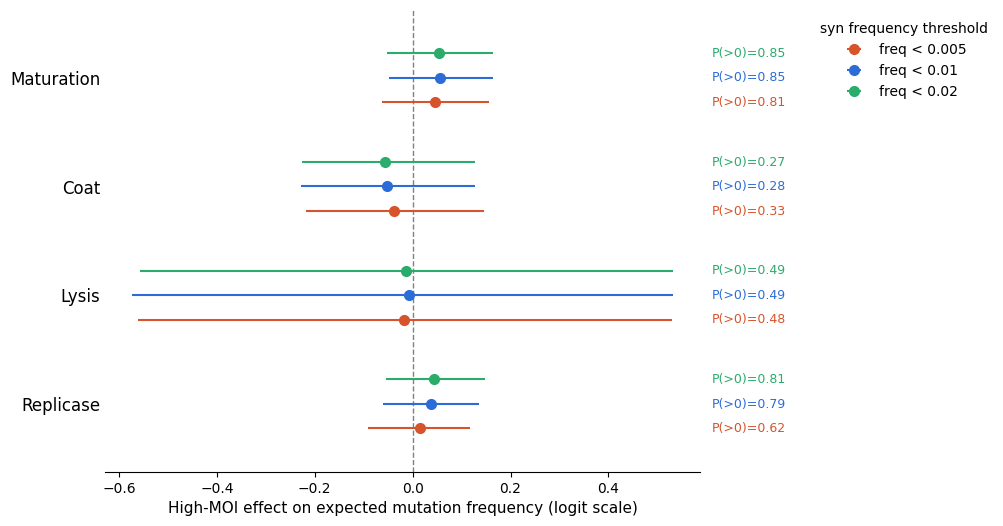

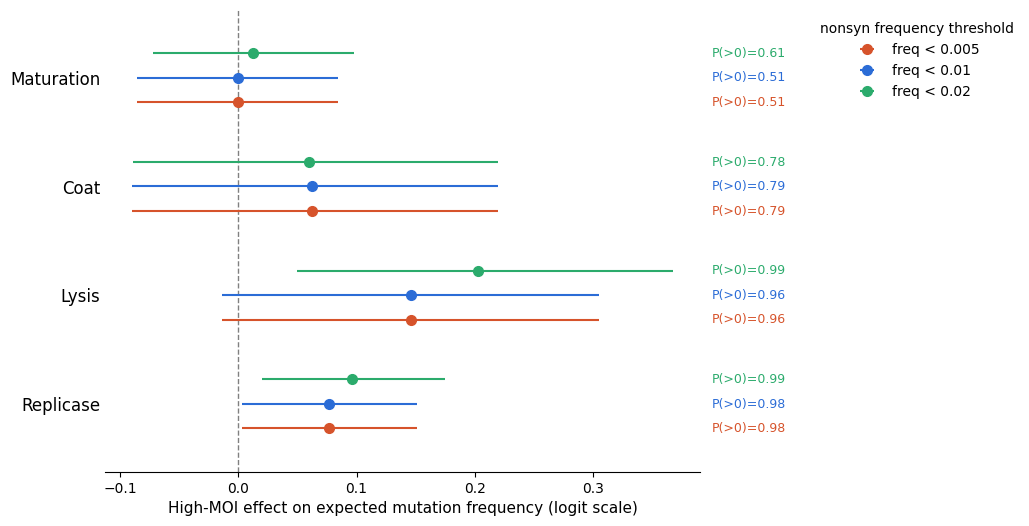

In [32]:
fig, ax = plot_moi_forest_multi(
    summary_dfs=[syn_05percent['summary'], syn_1percent['summary'],syn_2percent['summary']],
    prob_positive_dfs=[syn_05percent['prob_positive'], syn_1percent['prob_positive'],syn_2percent['prob_positive']],
    labels=["freq < 0.005", "freq < 0.01","freq < 0.02"],
    legend_title="syn frequency threshold"
)

fig, ax = plot_moi_forest_multi(
    summary_dfs=[ns_05percent['summary'], ns_1percent['summary'],ns_2percent['summary']],
    prob_positive_dfs=[ns_05percent['prob_positive'], ns_1percent['prob_positive'],ns_2percent['prob_positive']],
    labels=["freq < 0.005", "freq < 0.01","freq < 0.02"],
    legend_title="nonsyn frequency threshold"
)  

# NN performance

In [33]:
def plot_comparative_diagnostics(df_a, df_b, param_to_name, output_dir, save_fig, 
                                 plot_type='both', label_a='Stage 1', label_b='Stage 2'):
    plt.rcParams.update({'mathtext.fontset': 'stix'})
    if save_fig:
        os.makedirs(output_dir, exist_ok=True)

    params_a = set(df_a['parameter'].unique())
    params_b = set(df_b['parameter'].unique())
    all_params_list = sorted(list(params_a | params_b)) 
    n_params = len(all_params_list)

    color_a = 'tab:blue' #"xkcd:sky blue"# 'steelblue'
    color_b = 'tab:green' #'forestgreen' 

    if plot_type == 'both':
        rows, cols = 8, 4 
        figsize = (22, 36)
    else:
        rows, cols = 4, 4 
        figsize = (20, 22)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes_flat = axes.flatten()

    for i, p_name in enumerate(all_params_list):
        display_name = param_to_name.get(p_name, p_name)
        
        if plot_type == 'both':
            ax_parity = axes_flat[2 * i]
            ax_hist = axes_flat[2 * i + 1]
        elif plot_type == 'parity':
            ax_parity = axes_flat[i]
        else: 
            ax_hist = axes_flat[i]

        sub_a = df_a[df_a['parameter'] == p_name] if p_name in params_a else None
        sub_b = df_b[df_b['parameter'] == p_name] if p_name in params_b else None

        # --- Plot 1: Parity Plot (using ax.scatter) ---
        if plot_type in ['both', 'parity']:
            if sub_a is not None:
                ax_parity.scatter(sub_a["true_value"], sub_a["MAP_estimate"], 
                                  color=color_a, alpha=0.5, edgecolors='none', s=20,
                                  label=label_a if i == 0 else None)
            if sub_b is not None:
                ax_parity.scatter(sub_b["true_value"], sub_b["MAP_estimate"], 
                                  color=color_b, alpha=0.5, edgecolors='none', s=20,
                                  label=label_b if i == 0 else None)
            
            # Identity Line
            ax_parity.plot([-2, 2], [-2, 2], 'r--', alpha=0.8)
            ax_parity.set_xlim(-2, 2)
            ax_parity.set_ylim(-2, 2)
            
            ax_parity.set_title(display_name, fontsize=14, fontweight='bold', pad=15)
            ax_parity.set_xlabel("True Value", fontsize=12)
            ax_parity.set_ylabel("MAP Estimate", fontsize=12)
            if i == 0:
                ax_parity.legend(loc='upper left', fontsize=14, frameon=True)

        # --- Plot 2: Histogram Plot (using ax.hist) ---
        if plot_type in ['both', 'hist']:
            # Define bins to ensure both models use the same scale
            curr_xlim = (-1.05, 1.05) if i < 10 else (-0.2, 0.2)
            bins_for_this_plot = np.linspace(curr_xlim[0], curr_xlim[1], 50)

            if sub_a is not None:
                log_ratio_a = np.log10(sub_a["ratio_MAP_true"] + 1e-9)
                ax_hist.hist(log_ratio_a, bins=bins_for_this_plot, color=color_a, alpha=0.3, 
                             histtype='stepfilled', edgecolor='none', density=True,
                             label=label_a if (i == 0 and plot_type == 'hist') else None)
            if sub_b is not None:
                log_ratio_b = np.log10(sub_b["ratio_MAP_true"] + 1e-9)
                ax_hist.hist(log_ratio_b, bins=bins_for_this_plot, color=color_b, alpha=0.4, 
                             histtype='stepfilled', edgecolor='none', density=True,
                             label=label_b if (i == 0 and plot_type == 'hist') else None)
            
            # Formatting
            ax_hist.set_xlim(curr_xlim)

                
            ax_hist.set_title(display_name, fontsize=22, fontweight='medium', pad=15)
            ax_hist.set_xlabel("log10(MAP Error Ratio)", fontsize=18, labelpad=10)
            ax_hist.set_ylabel("Density", fontsize=18, labelpad=10)
            
            if i == 0 and plot_type == 'hist':
                ax_hist.legend(loc='upper right', fontsize=16, frameon=True)

    # --- Separation Lines & Layout ---
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.subplots_adjust(hspace=0.7, wspace=0.3)
    
    for r in range(1, rows):
        ax_above = axes[r-1, 0]
        ax_below = axes[r, 0]
        bbox_above = ax_above.get_position()
        bbox_below = ax_below.get_position()
        y_pos = (bbox_above.y0 + bbox_below.y1) / 2

        line = mlines.Line2D([0.02, 0.98], [y_pos, y_pos], color='black', 
                             linewidth=1.0, linestyle='--', alpha=0.2,
                             transform=fig.transFigure, figure=fig)
        fig.add_artist(line)

    if save_fig:
        save_path = os.path.join(output_dir, f"comparison_16params_{plot_type}.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved to {save_path}")
    else:
        plt.show()
        
def plot_comparison_wrapper(path_a, path_b, param_2_name, output_dir=None, save_fig=False, plot_type='both'):
    df_a = pd.read_csv(path_a)
    df_b = pd.read_csv(path_b)
    plot_comparative_diagnostics(df_a, df_b, param_2_name, output_dir, save_fig, plot_type=plot_type)

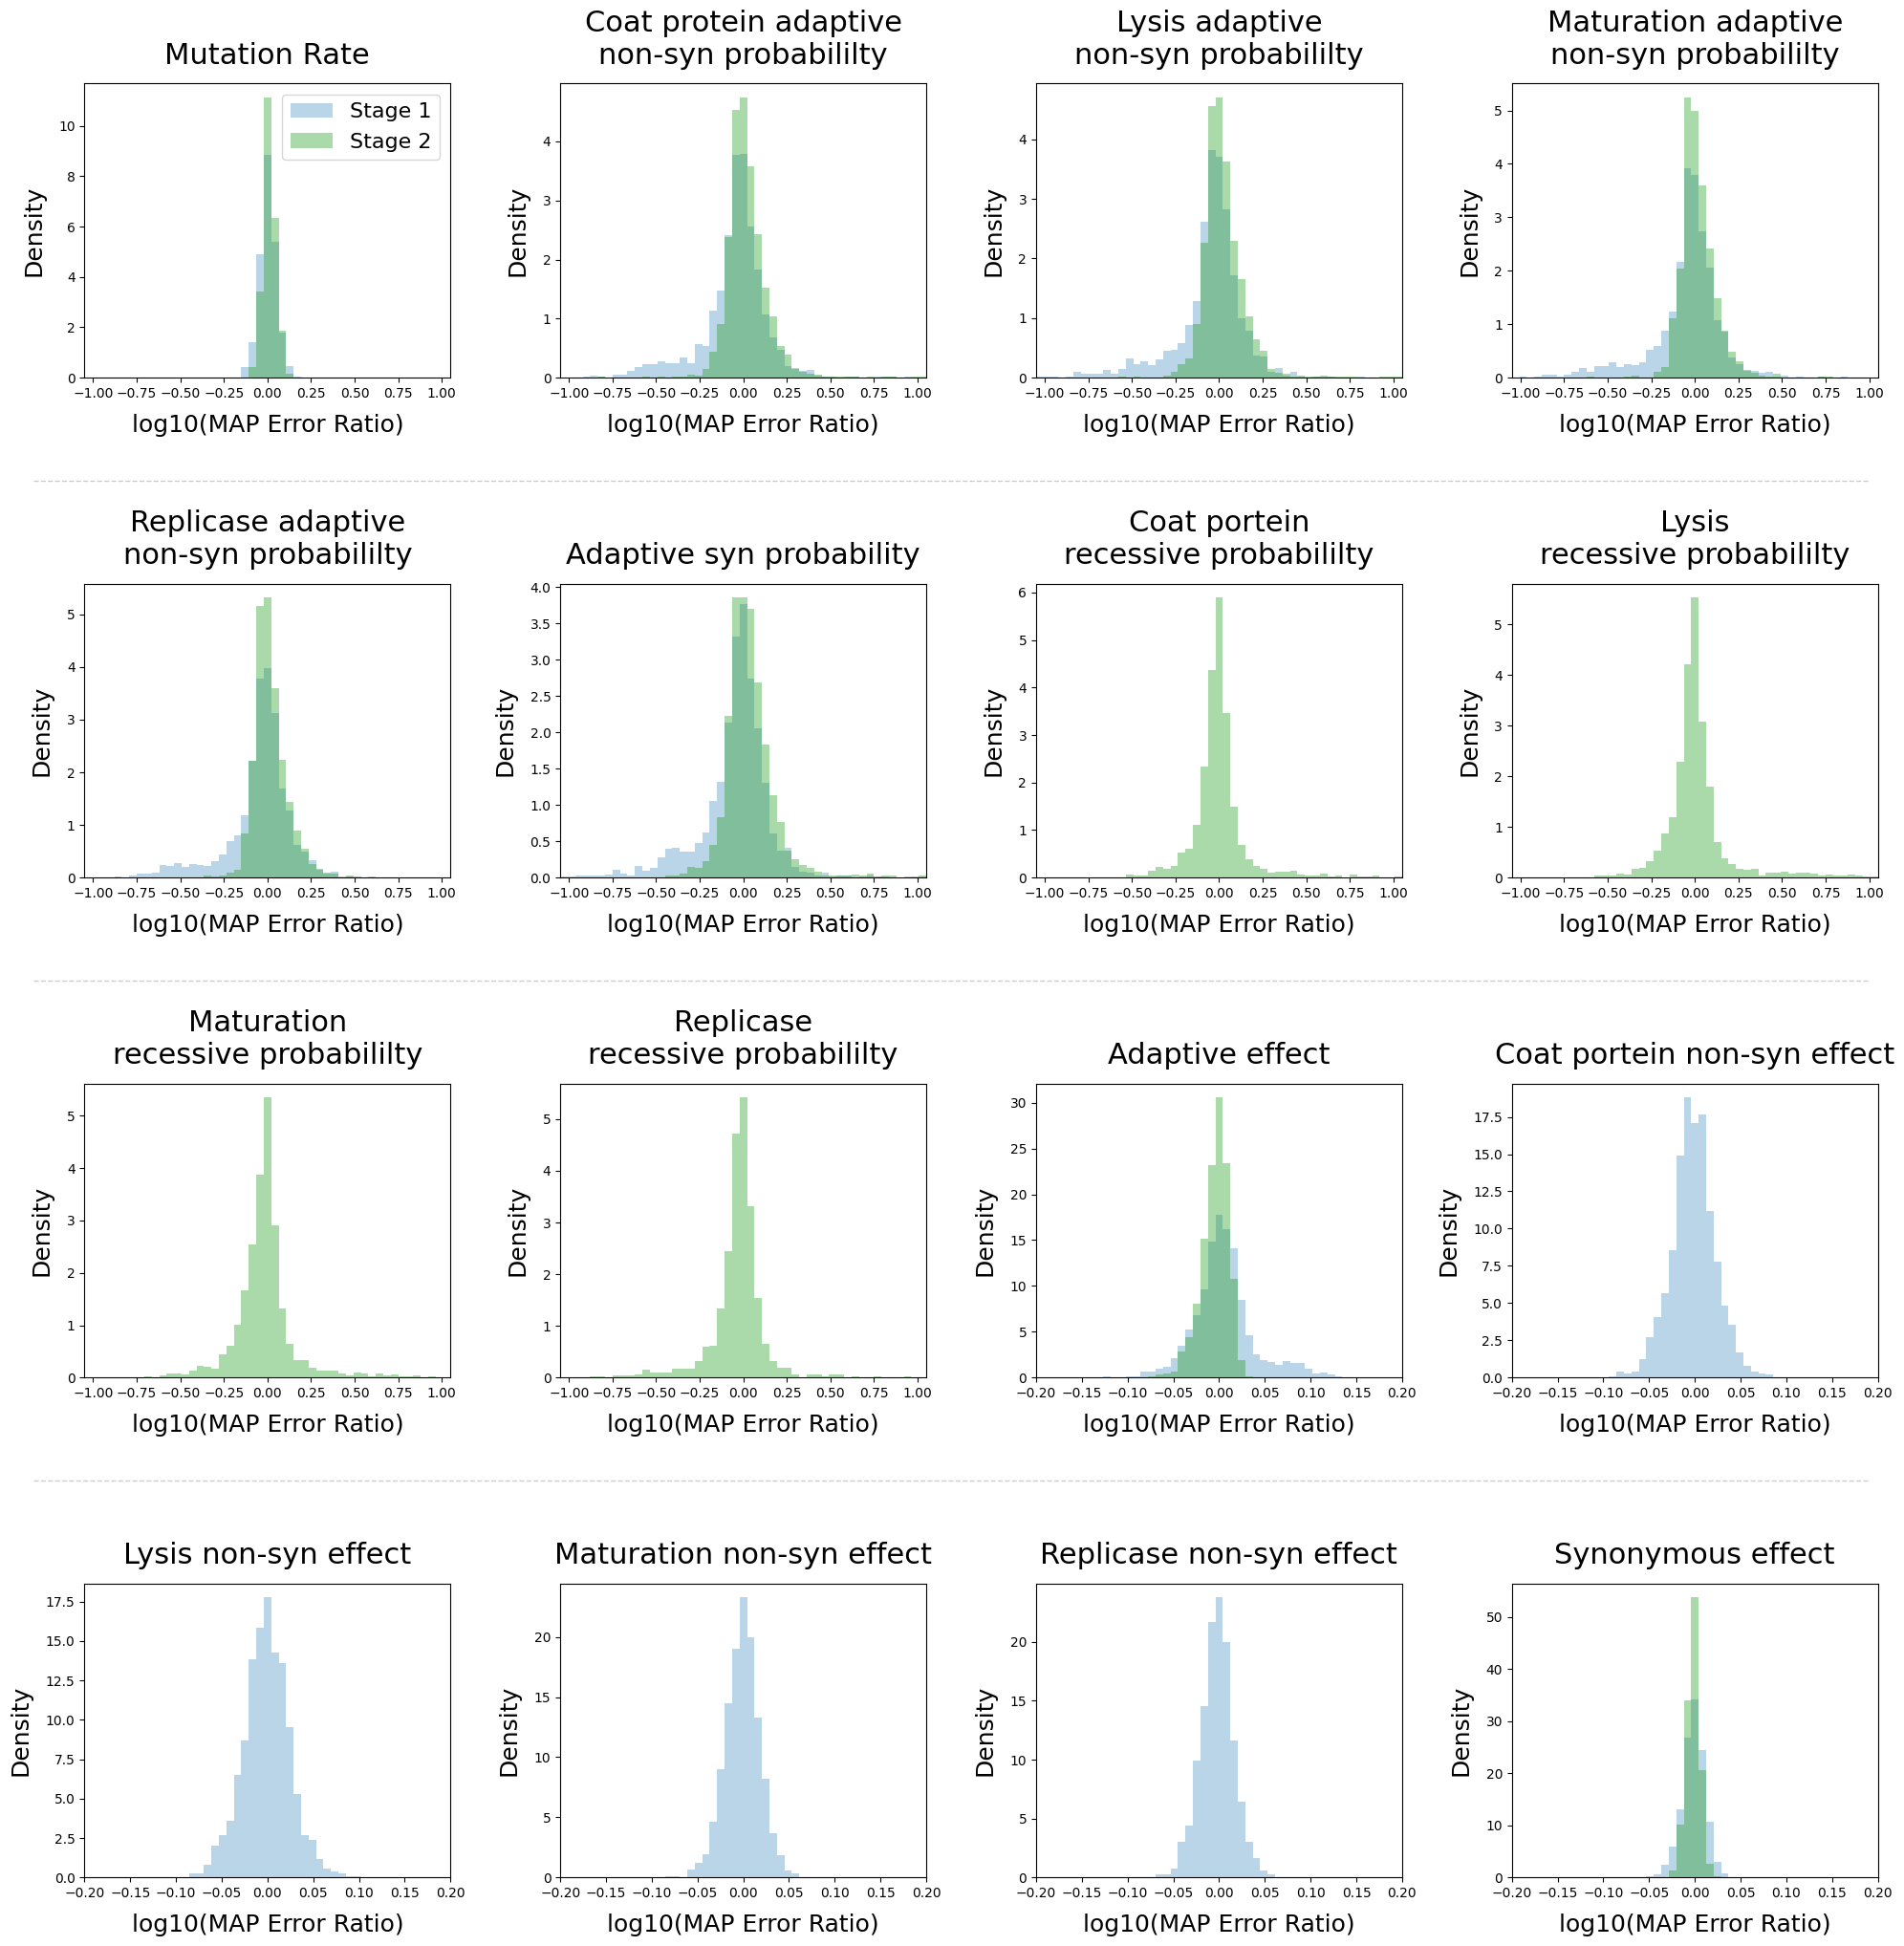

In [37]:
plot_comparison_wrapper(modelA_test_results_path,nn_test_modelB_weakada_output_path,param_2_name,output_dir=None, save_fig=False, plot_type='hist')

### PPC - posterior sampling

In [38]:
MODEL_B_PARAM_NAMES = list(modelB_priors.keys())

DEFAULT_FIXED_NONSYN_FITNESS = [
    0.81512636,  # w_nonsyn_mat
    0.71488076,  # w_nonsyn_cp
    0.7286895,  # w_nonsyn_lys
    0.7717157,  # w_nonsyn_rep
]

In [39]:
def simulate_ppc_from_posterior_samples_AB(
    posterior_thetas,
    model="B",
    fixed_param_lst=DEFAULT_FIXED_NONSYN_FITNESS,
    pop_size=pop_size_A,
    seq_err_rate=1e-5,
    seq_sample_size=1309,
    simulate_sequence_sampling=True,
    long_sumstat=0,
    passages_to_extract=[10],
    save_all_passages_path=None,
    save_wrangled_dir=None,          # NEW
    save_theta_per_sim=True,         # NEW
):
    """
    Simulate one dataset per sampled posterior theta.

    Optionally saves the wrangled dataframe from each simulation before
    it is collapsed into summary statistics.

    Returns
    -------
    extracted : torch.Tensor or dict[int, torch.Tensor]
        If passages_to_extract has one passage, returns tensor shape (n_sims, 10).
        If multiple passages, returns {passage: tensor shape (n_sims, 10)}.

    all_sims : torch.Tensor
        Full simulator output, usually shape (n_sims, 110) for short sumstats.

    wrangled_paths : list[str]
        Paths to saved wrangled simulation dataframes.
    """

    syn_probs_by_gene_lst = [
        syn_probs_by_gene["p_mat_syn"],
        syn_probs_by_gene["p_cp_syn"],
        syn_probs_by_gene["p_lys_syn"],
        syn_probs_by_gene["p_rep_syn"],
    ]

    gene_probs_lst = [
        gene_probs["p_mat"],
        gene_probs["p_cp"],
        gene_probs["p_lys"],
        gene_probs["p_rep"],
    ]

    if save_wrangled_dir is not None:
        os.makedirs(save_wrangled_dir, exist_ok=True)

    sims = []
    wrangled_paths = []

    thetas_lst = []
    if isinstance(posterior_thetas,pd.DataFrame):
        for i, row in posterior_thetas.iterrows():
            theta_lst = row.to_list()
            thetas_lst.append(theta_lst)
    else:        
        for i, theta in enumerate(posterior_thetas):
                # i += 5  # becuase i have 5 simulations and I want to add 15 more.
            theta_lst = theta.detach().cpu().numpy().tolist()
            thetas_lst.append(theta_lst)
            
    for i in range(len(thetas_lst)):
        theta_lst = thetas_lst[i]
        if i % 10 == 0:
            print(f"generated {i} / {len(posterior_thetas)} simulations")
        if save_wrangled_dir is None:
            sim = simulate_AB(
                sampled_params=theta_lst,
                syn_probs_by_gene=syn_probs_by_gene_lst,
                gene_probs=gene_probs_lst,
                model=model,
                passages=passages,
                seq_error_rate=seq_err_rate,
                pop_size=pop_size,
                fixed_params_lst=fixed_param_lst,
                sample_size=seq_sample_size,
                simulate_sequence_sampling=simulate_sequence_sampling,
                long_sumstat=long_sumstat,
            )
    
        else:
            sim, wrangled_df = simulate_AB(
                sampled_params=theta_lst,
                syn_probs_by_gene=syn_probs_by_gene_lst,
                gene_probs=gene_probs_lst,
                model=model,
                passages=passages,
                seq_error_rate=seq_err_rate,
                pop_size=pop_size,
                fixed_params_lst=fixed_param_lst,
                sample_size=seq_sample_size,
                simulate_sequence_sampling=simulate_sequence_sampling,
                return_data=True,
                long_sumstat=long_sumstat,
            )
    
            wrangled_path = os.path.join(
                save_wrangled_dir,
                f"ppc_sim_{i:04d}_wrangled.pkl",
            )
            wrangled_df.to_pickle(wrangled_path)
            wrangled_paths.append(wrangled_path)
    
            if save_theta_per_sim:
                theta_df = pd.DataFrame(
                    [theta_lst],
                    columns=MODEL_B_PARAM_NAMES,
                )
                theta_df.to_csv(
                    os.path.join(save_wrangled_dir, f"ppc_sim_{i:04d}_theta.csv"),
                    index=False,
                )

        sims.append(
            sim.detach().cpu() if isinstance(sim, torch.Tensor) else torch.as_tensor(sim)
        )

    all_sims = torch.stack(sims)

    if save_all_passages_path is not None:
        os.makedirs(os.path.dirname(save_all_passages_path), exist_ok=True)
        torch.save(all_sims, save_all_passages_path)

    extracted = extract_passages_from_short_sumstats(all_sims, passages_to_extract)

    return extracted, all_sims, wrangled_paths

In [ ]:
num_ppc_sims = 20

model_A_collective_posterior_samples_df = pd.read_csv(model_A_collective_posterior_samples_path)

collective_posterior_thetas_A = sample_thetas_from_conditioned_posterior_samples_df(model_A_collective_posterior_samples_df,num_ppc_sims)

display(collective_posterior_thetas_A.head())

collective_posterior_ppc_A_output_path = (
    "/sternadi/home/volume3/yael/model_AB/model_A/A1/PPC_weak_ada_def/modelA_PPC_collective_posterior_sampled_all_passages.pt"
)

colletive_wrangled_output_A_dir = (
    "/sternadi/home/volume3/yael/model_AB/model_A/A1/PPC_weak_ada_def/wrangled_collective_posterior_sampled_simulations/"
)

modelA_collective_posterior_ppc_p10, modelA_collective_posterior_ppc_all, wrangled_collective_paths_A = simulate_ppc_from_posterior_samples_AB(
    posterior_thetas=collective_posterior_thetas_A,
    model="A",
    fixed_param_lst=[0,0,0,0],
    pop_size=2 * 10**7,
    seq_err_rate=1e-5,
    seq_sample_size=1309,
    simulate_sequence_sampling=True,
    long_sumstat=0,
    passages_to_extract=[10],
    save_all_passages_path=collective_posterior_ppc_A_output_path,
    save_wrangled_dir=colletive_wrangled_output_A_dir,
    save_theta_per_sim=True,
)

torch.save(
    modelA_collective_posterior_ppc_p10,
    "/sternadi/home/volume3/yael/model_AB/model_A/A1/PPC_weak_ada_def/modelA_collective_posterior_ppc_p10.pt",
)

collective_posterior_thetas_A.to_csv(
    "/sternadi/home/volume3/yael/model_AB/model_A/A1/PPC_weak_ada_def/modelA_PPC_collective_posterior_sampled_thetas.csv",
    index=False,
)


In [ ]:
model_B_collective_posterior_samples_df = pd.read_csv(model_B_new_collective_EHG_samples_path)

collective_posterior_thetas_B = sample_thetas_from_conditioned_posterior_samples_df(model_B_collective_posterior_samples_df,num_ppc_sims)

collective_posterior_ppc_B_output_path = (
    "/sternadi/home/volume3/yael/model_AB/model_B/B_weak_ada_def/PPC/modelB_PPC_collective_posterior_sampled_all_passages.pt"
)

colletive_wrangled_output_B_dir = (
    "/sternadi/home/volume3/yael/model_AB/model_B/B_weak_ada_def/PPC/wrangled_collective_posterior_sampled_simulations/"
)

modelB_collective_posterior_ppc_p10, modelB_collective_posterior_ppc_all, wrangled_collective_paths_B = simulate_ppc_from_posterior_samples_AB(
    posterior_thetas=collective_posterior_thetas_B,
    model="B",
    fixed_param_lst=DEFAULT_FIXED_NONSYN_FITNESS,
    pop_size=2 * 10**7,
    seq_err_rate=1e-5,
    seq_sample_size=1309,
    simulate_sequence_sampling=True,
    long_sumstat=0,
    passages_to_extract=[10],
    save_all_passages_path=collective_posterior_ppc_B_output_path,
    save_wrangled_dir=colletive_wrangled_output_B_dir,
    save_theta_per_sim=True,
)

torch.save(
    modelB_collective_posterior_ppc_p10,
    "/sternadi/home/volume3/yael/model_AB/model_B/B_weak_ada_def/PPC/modelB_collective_posterior_ppc_p10.pt",
)

collective_posterior_thetas_B.to_csv(
    "/sternadi/home/volume3/yael/model_AB/model_B/B_weak_ada_def/PPC/modelB_PPC_collective_posterior_sampled_thetas.csv",
    index=False,
)

In [40]:
def sum_mut_freqs(x):
    """
    Input columns:
    0  Mat nonsyn non-ada
    1  Mat nonsyn ada
    2  CP nonsyn non-ada
    3  CP nonsyn ada
    4  Lys nonsyn non-ada
    5  Lys nonsyn ada
    6  Rep nonsyn non-ada
    7  Rep nonsyn ada
    8  Total syn non-ada
    9  Total syn ada

    Returns columns:
    0  Mat nonsyn total
    1  CP nonsyn total
    2  Lys nonsyn total
    3  Rep nonsyn total
    4  Total syn total
    """

    return x[..., [0, 2, 4, 6, 8]] + x[..., [1, 3, 5, 7, 9]]

In [42]:
modelA_collective_posterior_ppc_p10 = torch.load("/sternadi/home/volume3/yael/model_AB/model_A/A1/PPC_weak_ada_def/modelA_collective_posterior_ppc_p10.pt")
modelB_collective_posterior_ppc_p10 = torch.load("/sternadi/home/volume3/yael/model_AB/model_B/B_weak_ada_def/PPC/modelB_collective_posterior_ppc_p10.pt")

In [47]:
modelA_collective_posterior_ppc_p10_for_ppc = sum_mut_freqs(modelA_collective_posterior_ppc_p10)
emp_01_for_ppc = sum_mut_freqs(np.array(list(emp_dict_01.values())))

modelB_collective_posterior_ppc_p10_for_ppc = sum_mut_freqs(modelB_collective_posterior_ppc_p10)
emp_10_for_ppc = sum_mut_freqs(np.array(list(emp_dict_10.values())))

In [48]:
def plot_ppc_summary(empirical, simulations, MOI=10, save_path=None):
    """
    Plot posterior predictive checks summary.

    Parameters
    ----------
    empirical : array-like, shape (n_empirical_lines, 5)
        Empirical vectors. Each row is one empirical line.
    simulations : array-like, shape (n_simulations, 5)
        Simulated vectors from posterior samples.
    MOI : int
        MIO for legend: 10 or 0.1.
    save_path : str or None
        If given, saves the figure to this path.

    Output vector order is assumed to be:
    [Maturation nonsyn total,
     Coat nonsyn total,
     Lysis nonsyn total,
     Replicase nonsyn total,
     Total syn]
    """

    # Convert inputs to numpy
    if hasattr(empirical, "detach"):   # torch tensor
        empirical = empirical.detach().cpu().numpy()
    else:
        empirical = np.asarray(empirical)

    if hasattr(simulations, "detach"):  # torch tensor
        simulations = simulations.detach().cpu().numpy()
    else:
        simulations = np.asarray(simulations)

    labels = [
        "Maturation\nnonsyn",
        "Coat\nnonsyn",
        "Lysis\nnonsyn",
        "Replicase\nnonsyn",
        "Total\nsyn"
    ]

    # Empirical summary
    emp_median = np.median(empirical, axis=0)

    # Simulation summary
    sim_median = np.median(simulations, axis=0)
    sim_low = np.percentile(simulations, 2.5, axis=0)
    sim_high = np.percentile(simulations, 97.5, axis=0)

    x = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=(7, 4))

    # Simulations: median + 95% interval
    yerr = np.vstack([sim_median - sim_low, sim_high - sim_median])
    ax.errorbar(
        x, sim_median, yerr=yerr,
        fmt='o', capsize=3,capthick=2,ecolor='royalblue', elinewidth=2, markersize=6.5,color='royalblue', alpha=0.98,
        label='Simulations (median and 95% interval)'
    )

    # Empirical: median only
    ax.scatter(
        x, emp_median,
        s=45,
        marker='o',
        label=f'Empirical MOI-{MOI} (median)',
        color='darkgray',zorder=3,alpha=0.95
    ) 

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('mutation frequency sum', fontsize=16, labelpad=10)
    # ax.set_title(title)
    ax.legend(frameon=True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

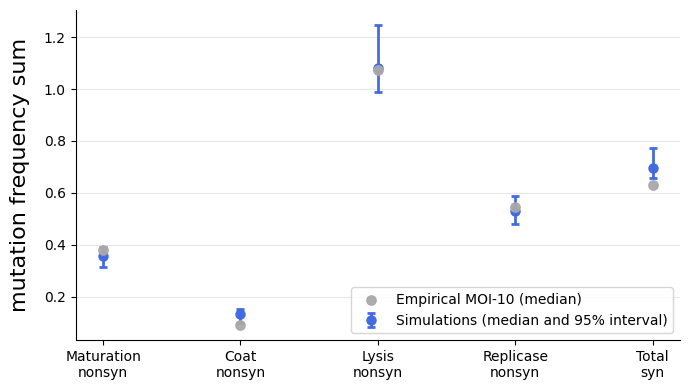

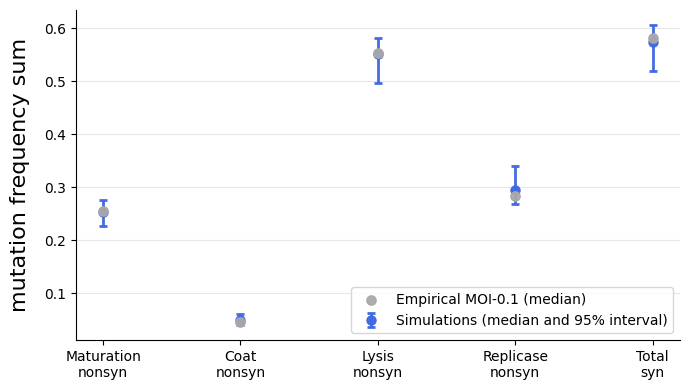

In [49]:
plot_ppc_summary(emp_10_for_ppc, modelB_collective_posterior_ppc_p10_for_ppc,10)
plot_ppc_summary(emp_01_for_ppc, modelA_collective_posterior_ppc_p10_for_ppc,0.1)